# ECoG Beta 频带百分比进程特征与两轮聚类 Notebook

这个 Notebook 将项目主流程集成为可从上到下运行的分析流程：读取 clean-CAR ECoG FIF、语音 onset/offset 事件、同步 WAV 音频，仅提取 beta 频带，将每个 trial 的 onset-offset 区间归一化为 0-100% 进程，并以 beta 能量斜率与语音包络变化的交互特征作为聚类重点。

脑表面共显示放在最后的可选单元格里。没有 FreeSurfer、pial surface 或 PyVista 时，可以正常完成特征提取和聚类主流程。

## 1. 初始化环境

如果你在 VS Code 中打开本文件，建议选择当前项目的 `.venv` 作为 Notebook kernel。

In [184]:
from __future__ import annotations

import os
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "audio_cross_3band_utils.py").is_file():
    PROJECT_DIR = Path(r"I:\贝塔频带汇报-2026-10")

os.environ.setdefault("_MNE_FAKE_HOME_DIR", str(PROJECT_DIR / ".mne-home"))
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_DIR / ".mplconfig"))
(PROJECT_DIR / ".mne-home").mkdir(exist_ok=True)
(PROJECT_DIR / ".mplconfig").mkdir(exist_ok=True)

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# 清理 Notebook kernel 中可能缓存的旧版本本地模块。
for module_name in ("audio_cross_3band_utils", "clustering_pipeline", "visualization"):
    sys.modules.pop(module_name, None)

from audio_cross_3band_utils import build_beta_progress_feature_table_from_files
from clustering_pipeline import (
    cluster_electrodes,
    combine_bad_channels,
    default_beta_progress_feature_weights,
    refit_after_bad_channel_review,
)
from visualization import (
    BadChannelReviewWindow,
    plot_beta_cluster_grid,
    plot_beta_progress_cluster_dynamics,
    plot_pca_clusters,
    plot_two_nonoverlapping_beta_trials,
    render_electrode_clusters,
    render_selectable_electrode_class,
)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

print(f"项目目录: {PROJECT_DIR}")

项目目录: i:\贝塔频带汇报-2026-10


## 2. 参数区

通常只需要改这一格。`EVENT_SOURCE` 可以是包含 onset 和 offset 两列的 CSV/TSV/NPY，也可以只给 onset 数组并在 `OFFSET_SOURCE` 中提供 offset 数组。

In [244]:
ECOG_DATA_ROOT = Path(r"I:\ECoG_data")
SUBJECT_ID = "HS0015"
BLOCK_ID = "B05"
DATA_DIR = ECOG_DATA_ROOT / SUBJECT_ID / "blocks" / BLOCK_ID / "standardized"
RECON_DIR = ECOG_DATA_ROOT / SUBJECT_ID / "recon"

# HS0016 B03 数据路径。
FIF_PATH = DATA_DIR / "ECoG" / "ecog_TEST_clean_car-raw.fif"
EVENT_SOURCE = DATA_DIR / "events" / "onset.npy"
OFFSET_SOURCE = DATA_DIR / "events" / "offset.npy"
WAV_PATH = DATA_DIR / "audio" / "analog1.wav"

# 输出目录。
OUTPUT_DIR = PROJECT_DIR / "outputs" / SUBJECT_ID / BLOCK_ID

# MNE picks。默认使用所有 data channels。
PICKS = "data"

# Beta-only 百分比进程设置。
PROGRESS_POINTS = 101
DURATION_MAD_THRESHOLD = 2.5
MIN_TRIALS_AFTER_FILTER = 3

# None 表示自动使用有效 trial 的最小 intertrial gap，即 onset[n+1] - offset[n]。
PRE_POST_WINDOW_SECONDS = None

# 聚类特征权重：强调 beta 斜率和音频包络变化的交互，弱化能量高低。
USE_BETA_PROGRESS_WEIGHTS = True
SLOPE_AUDIO_WEIGHT = 5
BETA_SLOPE_WEIGHT = 5
ENERGY_LEVEL_WEIGHT = 3

# 聚类设置。
FIRST_N_CLUSTERS = 10
SECOND_N_CLUSTERS = 4
RANDOM_STATE = 50

# 第一轮后复审：可以直接在这里填写，也可以把 OPEN_REVIEW_WINDOW 设为 True 打开 Tk 窗口。
BAD_CLUSTERS: tuple[int, ...] = ()
MANUAL_BADS: tuple[str, ...] = ()
OPEN_REVIEW_WINDOW = True

# 可选脑表面或三维电极显示。默认关闭。
RUN_3D_RENDER = True
ELECTRODE_CSV = RECON_DIR / "electrodes" / "electrodes.csv"
SUBJECTS_DIR = ECOG_DATA_ROOT / SUBJECT_ID
SUBJECT = "recon"
REFERENCE_MRI = RECON_DIR / "mri" / "T1.mgz"
HEMISPHERES = ("lh",)
TUMOR_NIFTI = None

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"输出目录: {OUTPUT_DIR}")

输出目录: i:\贝塔频带汇报-2026-10\outputs\HS0015\B05


## 3. 路径检查

如果这里报错，先回到上一格修改路径。

In [245]:
def optional_path(value: object) -> Path | None:
    if value is None:
        return None
    text = str(value).strip()
    if not text or text.lower() == "none":
        return None
    return Path(text)


FIF_PATH = Path(FIF_PATH)
EVENT_SOURCE = Path(EVENT_SOURCE)
OFFSET_SOURCE = optional_path(OFFSET_SOURCE)
WAV_PATH = Path(WAV_PATH)

required_paths = {
    "FIF_PATH": FIF_PATH,
    "EVENT_SOURCE": EVENT_SOURCE,
    "WAV_PATH": WAV_PATH,
}
if OFFSET_SOURCE is not None:
    required_paths["OFFSET_SOURCE"] = OFFSET_SOURCE

missing = {name: path for name, path in required_paths.items() if not path.is_file()}
if missing:
    detail = "\n".join(f"- {name}: {path}" for name, path in missing.items())
    raise FileNotFoundError("请先在参数区修改以下不存在的路径:\n" + detail)

print("路径检查通过")

路径检查通过


## 4. 特征提取

这一格会执行 beta 频带滤波、Hilbert 功率、duration outlier 剔除、0-100% trial 进程重采样、逐 trial 基线 Z 标准化、音频包络对齐和电极级斜率-音频交互特征提取。根据数据长度和通道数，运行时间可能较长。

In [246]:
features, beta_epochs = build_beta_progress_feature_table_from_files(
    fif_path=FIF_PATH,
    event_source=EVENT_SOURCE,
    offset_source=OFFSET_SOURCE,
    wav_path=WAV_PATH,
    picks=PICKS,
    progress_points=PROGRESS_POINTS,
    duration_mad_threshold=DURATION_MAD_THRESHOLD,
    min_trials_after_filter=MIN_TRIALS_AFTER_FILTER,
    pre_post_window=PRE_POST_WINDOW_SECONDS,
)

feature_csv = OUTPUT_DIR / "electrode_features.csv"
features.to_csv(feature_csv, index=False, encoding="utf-8-sig")

dropped_csv = OUTPUT_DIR / "dropped_trials_beta_progress.csv"
beta_epochs.dropped_events.to_csv(dropped_csv, index=False, encoding="utf-8-sig")

print(f"保留 trial 数: {len(beta_epochs.events)}")
print(f"剔除 trial 数: {len(beta_epochs.dropped_events)}")
print(f"通道数: {len(beta_epochs.channel_names)}")
print(f"特征表形状: {features.shape}")
print(f"beta 频带: {beta_epochs.beta_band[0]:.1f}-{beta_epochs.beta_band[1]:.1f} Hz")
print(f"pre/post 窗口: {beta_epochs.pre_post_window:.3f} s")
print(f"初始坏道数: {int(features['is_bad'].sum()) if 'is_bad' in features else 0}")
print(f"已保存: {feature_csv}")
print(f"已保存: {dropped_csv}")
display(features.head())

Reading 0 ... 107600  =      0.000 ...   269.000 secs...
保留 trial 数: 47
剔除 trial 数: 2
通道数: 128
特征表形状: (128, 29)
beta 频带: 13.0-30.0 Hz
pre/post 窗口: 1.334 s
初始坏道数: 4
已保存: i:\贝塔频带汇报-2026-10\outputs\HS0015\B05\electrode_features.csv
已保存: i:\贝塔频带汇报-2026-10\outputs\HS0015\B05\dropped_trials_beta_progress.csv


,channel,is_bad,beta_progress__energy_mean,beta_progress__energy_std,beta_progress__energy_auc,beta_progress__energy_peak_abs,beta_progress__energy_peak_percent,beta_progress__energy_range,beta_progress__pre_mean,beta_progress__post_mean,beta_progress__post_minus_pre_mean,beta_progress__beta_slope_mean,beta_progress__beta_slope_std,beta_progress__beta_slope_peak_abs,beta_progress__beta_slope_peak_percent,beta_progress__audio_slope_corr,beta_progress__audio_slope_reg_slope,beta_progress__audio_slope_xcorr,beta_progress__audio_slope_xcorr_lag_percent,beta_progress__slope_product_mean,beta_progress__slope_product_abs_mean,beta_progress__slope_same_sign_fraction,beta_progress__beta_slope_when_audio_rising,beta_progress__beta_slope_when_audio_falling,beta_progress__slope_crossing_count,beta_progress__first_slope_crossing_percent,beta_progress__trialwise_slope_audio_corr_mean,beta_progress__trialwise_slope_audio_corr_std,beta_progress__duration_slope_audio_corr
0,ECoG_1,False,-0.000086,0.000143,-0.008828,0.000329,100.0,0.000647,1.621237e-21,0.000094,0.000094,0.000004,0.000061,-0.000213,0.0,-0.071076,-0.000199,0.143490,-6.0,-9.542775e-08,8.161375e-07,0.514851,-0.000004,0.000017,33.0,9.0,-0.000388,0.103824,0.216445
1,ECoG_2,False,-0.000029,0.000193,-0.003110,0.000610,96.0,0.000828,-3.242474e-21,0.000189,0.000189,0.000006,0.000055,0.000194,92.0,0.007618,0.000019,-0.098584,4.0,8.927347e-09,6.235604e-07,0.445545,0.000005,0.000010,33.0,8.0,0.004793,0.095601,-0.011022
2,ECoG_3,False,-0.000016,0.000164,-0.001838,0.000551,93.0,0.000724,6.484948e-21,0.000187,0.000187,0.000006,0.000044,0.000194,92.0,0.016981,0.000034,-0.177371,5.0,1.611698e-08,4.606838e-07,0.514851,0.000008,0.000008,35.0,8.0,0.007913,0.090411,0.024570
3,ECoG_4,False,-0.000012,0.000132,-0.001316,0.000441,93.0,0.000574,-6.484948e-21,0.000178,0.000178,0.000005,0.000037,0.000184,100.0,0.016532,0.000028,-0.188023,20.0,1.317842e-08,3.538432e-07,0.475248,0.000008,0.000008,35.0,8.0,0.008633,0.087730,-0.010318
4,ECoG_5,False,-0.000038,0.000087,-0.003930,0.000263,93.0,0.000399,3.242474e-21,0.000131,0.000131,0.000004,0.000031,0.000186,100.0,0.006211,0.000009,-0.214452,5.0,4.007021e-09,2.802710e-07,0.514851,0.000008,0.000006,35.0,8.0,-0.006118,0.076594,-0.097840


## 5. 第一轮 K-means 聚类

第一轮只使用好通道拟合 `SimpleImputer`、`StandardScaler` 和 K-means。初始坏道标签固定为 `-1`，PCA 只用于可视化。

e:\anaconda\envs\ECoG_LR_v1\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,feature,weight
13,beta_progress__audio_slope_corr,5.0
14,beta_progress__audio_slope_reg_slope,5.0
25,beta_progress__trialwise_slope_audio_corr_std,5.0
24,beta_progress__trialwise_slope_audio_corr_mean,5.0
23,beta_progress__first_slope_crossing_percent,5.0
22,beta_progress__slope_crossing_count,5.0
21,beta_progress__beta_slope_when_audio_falling,5.0
20,beta_progress__beta_slope_when_audio_rising,5.0
19,beta_progress__slope_same_sign_fraction,5.0
18,beta_progress__slope_product_abs_mean,5.0


第一轮结果已保存: i:\贝塔频带汇报-2026-10\outputs\HS0015\B05\cluster_assignments_round1.csv


,n_electrodes
label,
-1,4
0,27
1,13
2,3
3,4
4,12
5,11
6,25
7,16


,channel,is_bad,label,pc1,pc2,pc3
0,ECoG_1,False,7,-3.192249,-1.908637,-4.291263
1,ECoG_2,False,0,-2.786543,-0.999628,2.208591
2,ECoG_3,False,6,-3.170556,0.311436,1.840511
3,ECoG_4,False,6,-3.324325,-0.098038,4.079127
4,ECoG_5,False,6,-3.276356,-1.468184,3.490726


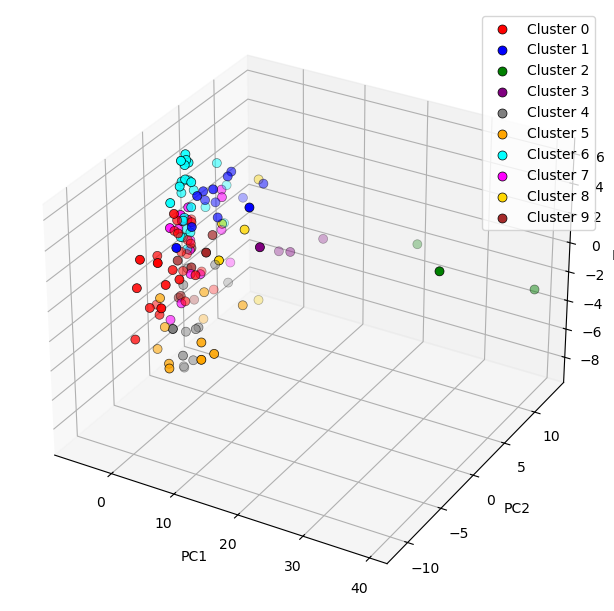

In [247]:
feature_weights = None
if USE_BETA_PROGRESS_WEIGHTS:
    feature_columns_for_weights = [
        column for column in features.columns
        if column not in {"channel", "is_bad"} and pd.api.types.is_numeric_dtype(features[column])
    ]
    feature_weights = default_beta_progress_feature_weights(
        feature_columns_for_weights,
        slope_audio_weight=SLOPE_AUDIO_WEIGHT,
        beta_slope_weight=BETA_SLOPE_WEIGHT,
        energy_weight=ENERGY_LEVEL_WEIGHT,
    )

first_result = cluster_electrodes(
    features,
    n_clusters=FIRST_N_CLUSTERS,
    feature_weights=feature_weights,
    random_state=RANDOM_STATE,
)

if feature_weights is not None:
    used_weights = pd.DataFrame(
        {
            "feature": first_result.feature_columns,
            "weight": first_result.feature_weights,
        }
    )
    used_weights.to_csv(OUTPUT_DIR / "beta_progress_feature_weights.csv", index=False, encoding="utf-8-sig")
    display(used_weights.sort_values("weight", ascending=False).head(15))

first_assignments = first_result.to_frame()
first_csv = OUTPUT_DIR / "cluster_assignments_round1.csv"
first_assignments.to_csv(first_csv, index=False, encoding="utf-8-sig")

fig, ax = plot_pca_clusters(
    first_result.pca_scores,
    first_result.labels,
    channel_names=first_result.channels,
    annotate=False,
)
fig.savefig(OUTPUT_DIR / "pca_clusters_round1.png", dpi=300, bbox_inches="tight")

print(f"第一轮结果已保存: {first_csv}")
display(first_assignments["label"].value_counts().sort_index().rename("n_electrodes").to_frame())
display(first_assignments.head())

## 6. 坏道复审与第二轮重拟合

如果要使用图形窗口复审，把参数区的 `OPEN_REVIEW_WINDOW` 改为 `True`。否则直接在参数区填写 `BAD_CLUSTERS` 和 `MANUAL_BADS`。第二轮会在排除所有坏道后重新拟合缺失值填充、标准化和 K-means，避免数据泄漏。

e:\anaconda\envs\ECoG_LR_v1\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


异常簇: ()
手动坏道: ()
合并坏道数: 4
第二轮 K: 4
第二轮结果已保存: i:\贝塔频带汇报-2026-10\outputs\HS0015\B05\cluster_assignments_round2.csv


,n_electrodes
label,
-1,4
0,77
1,28
2,3
3,16


,channel,is_bad,label,pc1,pc2,pc3
0,ECoG_1,False,0,-3.192249,-1.908637,-4.291263
1,ECoG_2,False,0,-2.786543,-0.999628,2.208591
2,ECoG_3,False,0,-3.170556,0.311436,1.840511
3,ECoG_4,False,0,-3.324325,-0.098038,4.079127
4,ECoG_5,False,0,-3.276356,-1.468184,3.490726


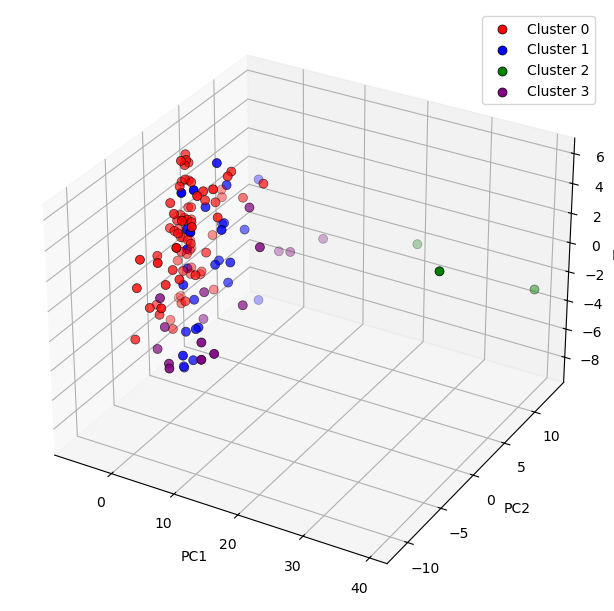

In [248]:
selected_bad_clusters = tuple(BAD_CLUSTERS)
selected_manual_bads = tuple(MANUAL_BADS)
selected_second_k = int(SECOND_N_CLUSTERS)

if OPEN_REVIEW_WINDOW:
    review = BadChannelReviewWindow(
        first_result,
        initial_second_k=selected_second_k,
    ).show()
    if review is not None:
        selected_bad_clusters = review.bad_clusters
        selected_manual_bads = review.manual_bads
        selected_second_k = review.n_clusters
    else:
        print("复审窗口已关闭，使用参数区中的复审设置。")

initial_bad_mask = features["is_bad"].fillna(False).to_numpy(bool)
combined_bad_mask = combine_bad_channels(
    first_result.channels,
    initial_bad_mask,
    first_result.labels,
    bad_clusters=selected_bad_clusters,
    manual_bads=selected_manual_bads,
)

second_result = refit_after_bad_channel_review(
    features,
    combined_bad_mask,
    n_clusters=selected_second_k,
    feature_columns=first_result.feature_columns,
    feature_weights=dict(zip(first_result.feature_columns, first_result.feature_weights)),
    random_state=RANDOM_STATE,
)

second_assignments = second_result.to_frame()
second_csv = OUTPUT_DIR / "cluster_assignments_round2.csv"
second_assignments.to_csv(second_csv, index=False, encoding="utf-8-sig")

assert np.all(second_result.labels[combined_bad_mask] == -1)

fig, ax = plot_pca_clusters(
    second_result.pca_scores,
    second_result.labels,
    channel_names=second_result.channels,
    annotate=False,
)
fig.savefig(OUTPUT_DIR / "pca_clusters_round2.png", dpi=300, bbox_inches="tight")

print(f"异常簇: {selected_bad_clusters}")
print(f"手动坏道: {selected_manual_bads}")
print(f"合并坏道数: {int(combined_bad_mask.sum())}")
print(f"第二轮 K: {selected_second_k}")
print(f"第二轮结果已保存: {second_csv}")
display(second_assignments["label"].value_counts().sort_index().rename("n_electrodes").to_frame())
display(second_assignments.head())

## 7. Beta-only 簇动态曲线

每个簇一个子图，只显示 beta。蓝/红/绿等颜色为簇内 ECoG beta Z-power 均值，阴影为 SEM；橙色为同步语音包络。虚线分别标记 onset 和归一化后的 median offset，灰色背景显示 onset 前和 offset 后窗口。

已保存 beta-only 簇动态图、诊断图和两个互不重叠 trial 示例图。


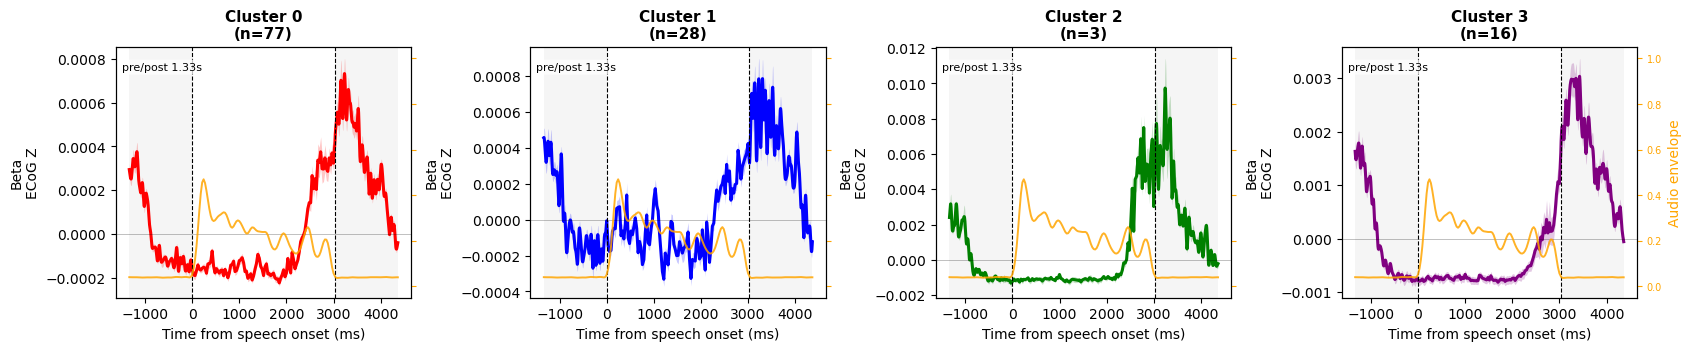

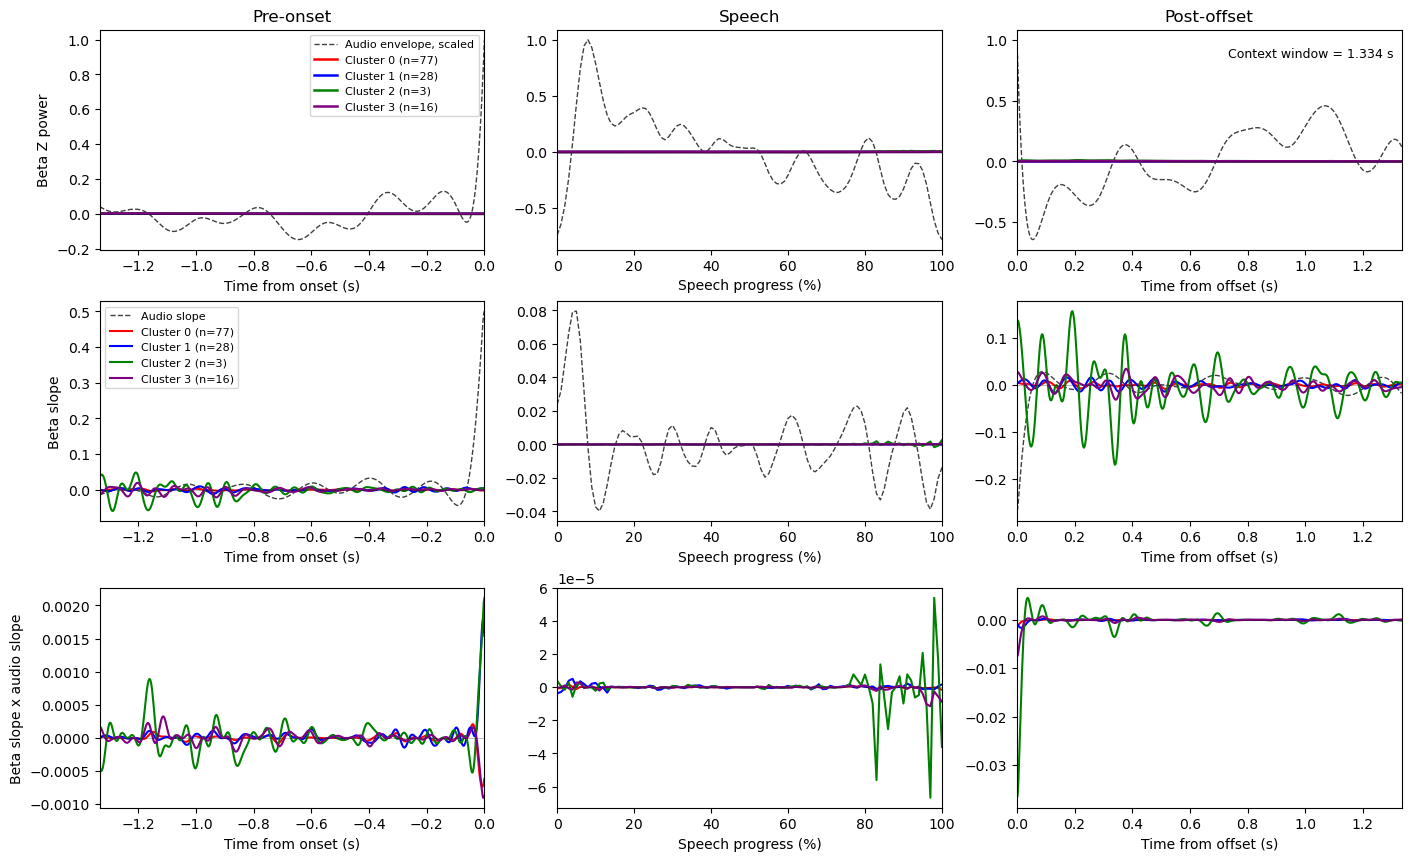

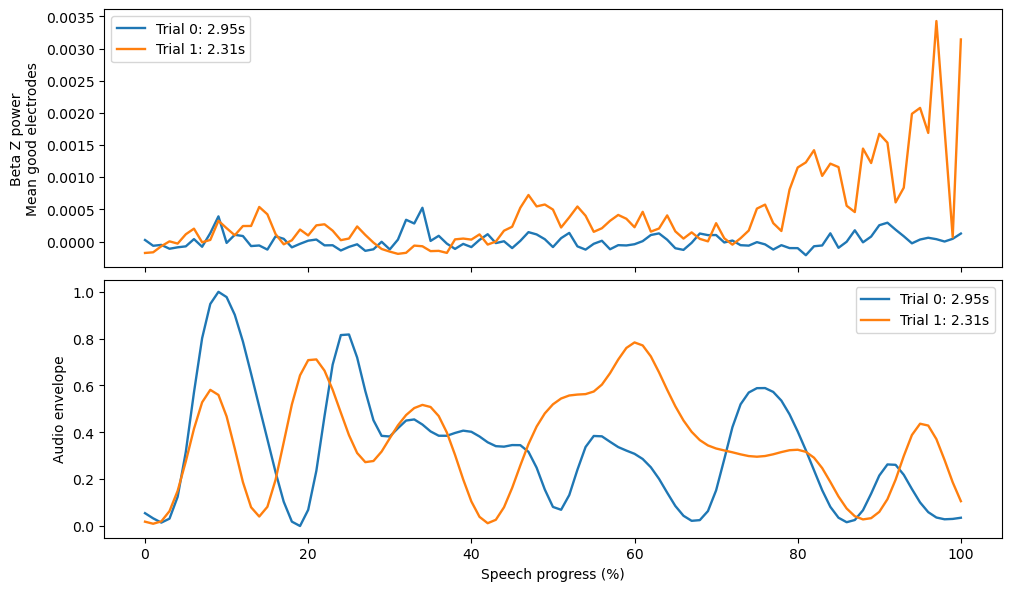

In [249]:
# Cell 7 曲线显示平滑参数。数值越大越平滑；设为 0 可显示原始均值曲线。
BETA_CURVE_SMOOTH_SIGMA_SECONDS = 0.001

fig_grid, axes_grid = plot_beta_cluster_grid(
    beta_epochs,
    second_result.labels,
    max_columns=5,
    sigma_seconds=BETA_CURVE_SMOOTH_SIGMA_SECONDS,
)
fig_grid.savefig(OUTPUT_DIR / "cluster_grid_beta_only.png", dpi=300, bbox_inches="tight")

# 诊断图：包含 beta power、beta slope 和 beta slope x audio slope 三行，可按需查看。
fig_progress, axes_progress = plot_beta_progress_cluster_dynamics(
    beta_epochs,
    second_result.labels,
    sigma_seconds=BETA_CURVE_SMOOTH_SIGMA_SECONDS,
)
fig_progress.savefig(OUTPUT_DIR / "cluster_dynamics_beta_progress_diagnostic.png", dpi=300, bbox_inches="tight")

fig_trials, axes_trials = plot_two_nonoverlapping_beta_trials(beta_epochs)
fig_trials.savefig(OUTPUT_DIR / "two_nonoverlapping_trials_beta_progress.png", dpi=300, bbox_inches="tight")

print("已保存 beta-only 簇动态图、诊断图和两个互不重叠 trial 示例图。")

## 8. 音频包络检查

这里显示跨 trial 平均后的音频包络，用于快速确认音频和 ECoG epoch 时间网格是否对齐。

音频包络图已保存。


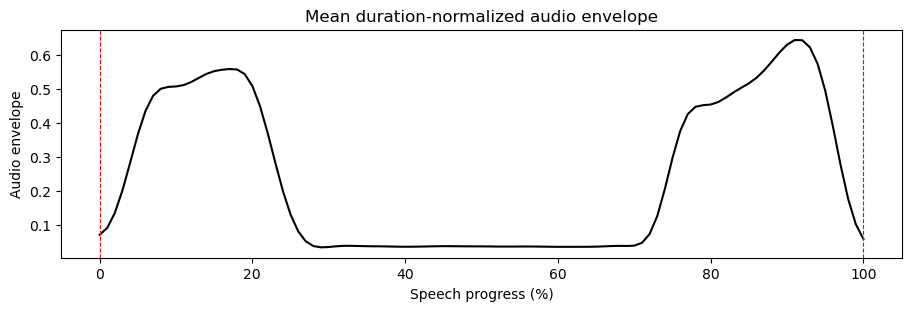

In [242]:
mean_audio = np.nanmean(beta_epochs.audio_speech, axis=0)

fig_audio, ax_audio = plt.subplots(figsize=(9, 3), constrained_layout=True)
ax_audio.plot(beta_epochs.progress_percent, mean_audio, color="black", linewidth=1.5)
ax_audio.axvline(0.0, color="red", linestyle="--", linewidth=0.8)
ax_audio.axvline(100.0, color="red", linestyle="--", linewidth=0.8)
ax_audio.set_xlabel("Speech progress (%)")
ax_audio.set_ylabel("Audio envelope")
ax_audio.set_title("Mean duration-normalized audio envelope")
fig_audio.savefig(OUTPUT_DIR / "mean_audio_envelope_progress.png", dpi=300, bbox_inches="tight")
print("音频包络图已保存。")

## 9. 可选三维电极或脑表面显示

默认不运行。需要先安装 `requirements-brain.txt` 中的可选依赖。若只提供 `ELECTRODE_CSV`，会在 Scanner RAS 空间显示电极；若同时提供 `SUBJECTS_DIR` 和 `SUBJECT`，则叠加 FreeSurfer pial surface。

In [243]:
# 脑表面显示参数。修改这一组即可调整 Cell 9 的 PyVista 弹窗效果。
BRAIN_COLOR = "ivory"
BRAIN_OPACITY = 1
BRAIN_SPECULAR = 0.08
TUMOR_COLOR = "yellow"
TUMOR_OPACITY = 0.30
ELECTRODE_POINT_SIZE = 14.0
BACKGROUND_COLOR = "white"
PYVISTA_WINDOW_SIZE = (1200, 900)
PYVISTA_CAMERA_POSITION = "xy"
SAVE_3D_SCREENSHOT = True

if RUN_3D_RENDER:
    if not Path(ELECTRODE_CSV).is_file():
        raise FileNotFoundError(f"电极坐标文件不存在: {ELECTRODE_CSV}")

    label_mapping = dict(zip(second_result.channels, map(int, second_result.labels)))
    screenshot_path = OUTPUT_DIR / "electrode_clusters_3d.png" if SAVE_3D_SCREENSHOT else None

    render_electrode_clusters(
        ELECTRODE_CSV,
        label_mapping,
        subjects_dir=SUBJECTS_DIR,
        subject=SUBJECT,
        reference_mri=REFERENCE_MRI,
        hemispheres=HEMISPHERES,
        tumor_nifti=TUMOR_NIFTI,
        point_size=ELECTRODE_POINT_SIZE,
        window_size=PYVISTA_WINDOW_SIZE,
        camera_position=PYVISTA_CAMERA_POSITION,
        brain_color=BRAIN_COLOR,
        brain_opacity=BRAIN_OPACITY,
        brain_specular=BRAIN_SPECULAR,
        tumor_color=TUMOR_COLOR,
        tumor_opacity=TUMOR_OPACITY,
        background_color=BACKGROUND_COLOR,
        screenshot=screenshot_path,
    )
    print(f"三维显示截图已保存: {screenshot_path}")
else:
    print("已跳过三维显示。将 RUN_3D_RENDER 改为 True 后可运行此单元格。")

三维显示截图已保存: i:\贝塔频带汇报-2026-10\outputs\HS0007\B08\electrode_clusters_3d.png


i:\贝塔频带汇报-2026-10\visualization.py:860: UserWarning: PyVista window opened, but screenshot was not saved: This plotter is closed and unable to save a screenshot.
  warnings.warn(f"PyVista window opened, but screenshot was not saved: {exc}")


## 10. 交互选择单类电极并改色

此单元会打开一个新的 PyVista 弹窗。窗口左上角的 `Cluster` 滑条用于选择只显示哪一类电极，`Red`、`Green`、`Blue` 滑条用于实时改变该类电极颜色。

In [211]:
# 单类电极交互显示参数。
# SELECTED_CLUSTER_LABEL 为 None 时自动选择第一个非坏道类别。
RUN_SELECTABLE_CLUSTER_RENDER = True
SELECTED_CLUSTER_LABEL = None
SELECTED_CLUSTER_COLOR = (1.0, 0.0, 0.0)
SELECTABLE_ELECTRODE_RADIUS = 1.6
SELECTABLE_SLIDER_LENGTH = 0.22
SELECTABLE_SLIDER_Y_GAP = 0.052
SELECTABLE_SLIDER_WIDTH = 0.016
SELECTABLE_SLIDER_TUBE_WIDTH = 0.004
SELECTABLE_SLIDER_TITLE_HEIGHT = 0.018
SELECTABLE_SLIDER_TEXT_FONT_SIZE = 8

if RUN_SELECTABLE_CLUSTER_RENDER:
    if not Path(ELECTRODE_CSV).is_file():
        raise FileNotFoundError(f"电极坐标文件不存在: {ELECTRODE_CSV}")

    label_mapping = dict(zip(second_result.channels, map(int, second_result.labels)))
    render_selectable_electrode_class(
        ELECTRODE_CSV,
        label_mapping,
        subjects_dir=SUBJECTS_DIR,
        subject=SUBJECT,
        reference_mri=REFERENCE_MRI,
        hemispheres=HEMISPHERES,
        tumor_nifti=TUMOR_NIFTI,
        selected_label=SELECTED_CLUSTER_LABEL,
        selected_color=SELECTED_CLUSTER_COLOR,
        electrode_radius=SELECTABLE_ELECTRODE_RADIUS,
        window_size=PYVISTA_WINDOW_SIZE,
        camera_position=PYVISTA_CAMERA_POSITION,
        brain_color=BRAIN_COLOR,
        brain_opacity=BRAIN_OPACITY,
        brain_specular=BRAIN_SPECULAR,
        tumor_color=TUMOR_COLOR,
        tumor_opacity=TUMOR_OPACITY,
        background_color=BACKGROUND_COLOR,
        slider_length=SELECTABLE_SLIDER_LENGTH,
        slider_y_gap=SELECTABLE_SLIDER_Y_GAP,
        slider_width=SELECTABLE_SLIDER_WIDTH,
        slider_tube_width=SELECTABLE_SLIDER_TUBE_WIDTH,
        slider_title_height=SELECTABLE_SLIDER_TITLE_HEIGHT,
        slider_text_font_size=SELECTABLE_SLIDER_TEXT_FONT_SIZE,
    )
    print("单类电极交互窗口已打开。")
else:
    print("已跳过单类电极交互显示。")

单类电极交互窗口已打开。


## 11. 输出文件汇总

In [ ]:
output_files = sorted(path.name for path in OUTPUT_DIR.glob("*"))
pd.DataFrame({"file": output_files})